# GZD-5 Classfication
___

## Setup

### Importing Packages

In [1]:
%matplotlib widget

import os
import shutil
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from umap import UMAP
from projectFunctions import feature_pre_processing, label_pre_processing, myBGMM, myMBKM, create_gz_evaluation_set, sorting_all_images, distance_bin_plots, confidence_bin_plots

### Directories

In [2]:
# Data Root Directory
data_root_dir = os.path.join(os.getcwd(), 'Data')

# Image Directory
img_dir = os.path.join(data_root_dir, 'Images')

# Label Directory
#label_dir = os.path.join(data_root_dir, 'gz_decals_volunteers_5.parquet')
#full_volunteer_labels = pd.read_parquet(label_dir)
#volunteer_labels = label_pre_processing(full_volunteer_labels, data_root_dir, img_dir)

# Refined Volunteer Labels Directory
refined_label_dir = os.path.join(data_root_dir, 'volunteer_labels.parquet')
volunteer_labels = pd.read_parquet(refined_label_dir)
print('Labelled Galaxies: ', volunteer_labels.shape)
print('Round Ellipticals: ',    (volunteer_labels['Volunteer_Label'] == 'R').sum())
print('Spirals: ',              (volunteer_labels['Volunteer_Label'] == 'S').sum())
print('Edge-ons: ',             (volunteer_labels['Volunteer_Label'] == 'E').sum())

# Feature Directory
#feature_dir = os.path.join(data_root_dir, 'GalaxyZoo_Main_Features.parquet')
#features = pd.read_parquet(feature_dir)
#pca_features = feature_pre_processing(features, data_root_dir)

# PCA Feature Directory
pca_feature_dir = os.path.join(data_root_dir, 'pca_features.parquet')
pca_features = pd.read_parquet(pca_feature_dir)
print(f'PCA features: {pca_features.shape}')    

Labelled Galaxies:  (24858, 127)
Round Ellipticals:  9464
Spirals:  12432
Edge-ons:  2962
PCA features: (230575, 29)


## Clustering

In [3]:
method = 'MBKM'
no_of_runs = 5
low_member_threshold = 300
low_percentage_threshold = 50

no_of_clusters_to_test = np.arange(3,41,1)
#no_of_clusters_to_test = np.array([20])

In [4]:
results = []
# Siloutte and David Bouldin scores are calculated on a random sample of 10,000 galaxies to reduce computation time
rng = np.random.default_rng(42)
metric_sample = rng.choice(len(pca_features), size=10000, replace=False)

for no_of_clusters in no_of_clusters_to_test:
    print(f"No. of Clusters: {no_of_clusters}")
    for i in range(no_of_runs):

        if method == 'MBKM':
            mbkm_inertia, silhouette, david, clusters = myMBKM(pca_features, n_clusters=no_of_clusters, max_iter=10, n_init=10, metric_sample=metric_sample)
            prefix = 'Distance'
        elif method == 'BGMM':
            bgmm_weights, bgmm_lower_bound, silhouette, david, clusters = myBGMM(pca_features, n_components=no_of_clusters, weight_concentration_prior=0.5, 
                                                                                 n_init=10, max_iter=1000, metric_sample=metric_sample)
            prefix = 'Prob'

        distance_cols = [f"{prefix}_{i}" for i in range(no_of_clusters)]
        distance_array = clusters[distance_cols].to_numpy()
        # Finding Assigned Distance by selecting the distance corresponding to the assigned cluster for each row
        clusters[f'Assigned_{prefix}'] = distance_array[np.arange(len(clusters)), clusters['Cluster'].to_numpy()]
        
        # PREDICTING FROM MODAL TEST SUBSET
        ####################################
        # Merging the cluster assignments with the confident labels
        test_subset = clusters.merge(volunteer_labels, left_index=True, right_index=True, how='inner')
        test_subset.to_parquet(os.path.join(data_root_dir, f'{method}_test_subset.parquet'))
        print('Labelled and Clustered Galaxies: ', test_subset.shape)

        # Group by Cluster and Type to find how many of each type in each cluster
        counts = test_subset.groupby(['Cluster', 'Volunteer_Label']).size()
        counts_df = counts.reset_index(name='Count')
        # Add Total and Percentage Accuracy Columns
        counts_df['Total'] = counts_df.groupby('Cluster')['Count'].transform('sum')
        counts_df['Percentage'] = counts_df['Count'] / counts_df['Total'] * 100
        low_member_clusters = counts_df[counts_df['Total'] < low_member_threshold]['Cluster'].unique()
        #print(f"Clusters with less than {low_member_threshold} members: {low_member_clusters}")
        #print(counts_df)

        # Find Dominant Type in Each Cluster
        dominant = counts_df.loc[counts_df.groupby('Cluster')['Count'].idxmax()]
        # Save Summary Array
        summary_df = dominant.set_index('Cluster')[['Volunteer_Label', 'Percentage']]
        summary_df.columns = ['Dominant_Type', 'Percentage']
        low_percentage_clusters = (summary_df[summary_df['Percentage'] < low_percentage_threshold].index).to_numpy()
        #print(f"Clusters with less than {low_percentage_threshold}% dominant type: {low_percentage_clusters}")
        #print(summary_df)

        # Map the dominant type to each galaxy based on its cluster assignment
        clusters["Dominant_Type"] = clusters["Cluster"].map(summary_df["Dominant_Type"])
        test_subset['Predicted_Label'] = test_subset['Cluster'].map(summary_df['Dominant_Type'])

        # EVALUATION METRICS
        ######################
        accuracy = accuracy_score(test_subset['Volunteer_Label'], test_subset['Predicted_Label'])
        print(f'Run {i + 1}')
        if method == 'MBKM':
            results.append({"n_clusters": no_of_clusters,
                            "run": i + 1,
                            "accuracy": accuracy,
                            "inertia": mbkm_inertia,
                            "silhouette": silhouette,
                            "david_bouldin": david})
        elif method == 'BGMM':
            results.append({"n_clusters": no_of_clusters,
                            "run": i + 1,
                            "accuracy": accuracy,
                            "weights": bgmm_weights,
                            "silhouette": silhouette,
                            "lower_bound": bgmm_lower_bound,
                            "david_bouldin": david})
        R_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'R']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'R']['Predicted_Label']) 
        S_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'S']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'S']['Predicted_Label']) 
        E_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'E']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'E']['Predicted_Label']) 
        
        print('Class Accuracy\n##############')
        print(f'R: {R_accuracy:.2f}')
        print(f'S: {S_accuracy:.2f}')
        print(f'E: {E_accuracy:.2f}')
        #print('\nClassification Report\n#####################')
        #print(classification_report(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E']))

results = pd.DataFrame(results)
print(results)

No. of Clusters: 3
Labelled and Clustered Galaxies:  (15721, 133)
Run 1
Class Accuracy
##############
R: 0.00
S: 1.00
E: 0.00
Labelled and Clustered Galaxies:  (15721, 133)
Run 2
Class Accuracy
##############
R: 0.12
S: 0.99
E: 0.00
Labelled and Clustered Galaxies:  (15721, 133)
Run 3
Class Accuracy
##############
R: 0.11
S: 0.97
E: 0.00
Labelled and Clustered Galaxies:  (15721, 133)
Run 4
Class Accuracy
##############
R: 0.01
S: 1.00
E: 0.00
Labelled and Clustered Galaxies:  (15721, 133)
Run 5
Class Accuracy
##############
R: 0.00
S: 0.93
E: 0.45
No. of Clusters: 4
Labelled and Clustered Galaxies:  (15721, 134)
Run 1
Class Accuracy
##############
R: 0.08
S: 0.98
E: 0.00
Labelled and Clustered Galaxies:  (15721, 134)
Run 2
Class Accuracy
##############
R: 0.18
S: 0.98
E: 0.00
Labelled and Clustered Galaxies:  (15721, 134)
Run 3
Class Accuracy
##############
R: 0.11
S: 0.98
E: 0.00
Labelled and Clustered Galaxies:  (15721, 134)
Run 4
Class Accuracy
##############
R: 0.09
S: 0.99
E: 0.00

In [ ]:
# Plotting the Confusion Matrix
fig, ax1 = plt.subplots(1,1,figsize=(8,6), constrained_layout=True)
cm = confusion_matrix(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Round Elliptical', 'Spiral', 'Edge-On'], )
disp.plot(ax=ax1, colorbar=False ,cmap=plt.cm.Blues)
ax1.tick_params(axis="y", rotation=90)
plt.title(f'{method}', fontsize=16)
plt.savefig(os.path.join('Data/Thesis Plots', f'{method}_confusion_matrix.png'), bbox_inches='tight')
display(fig)
plt.close(fig)

## Optimal Number of Clusters

### BGMM 

In [ ]:
print('Low Membership Clusters (<300): ',low_member_clusters)
print('Low Accuracy Clusters (<50%): ',low_percentage_clusters)

plt.close('all')
weights = results['weights'].iat[0]
x_val = np.arange(len(weights))

plt.figure(figsize=(8, 6))
plt.scatter(x_val, weights)

for x, y in zip(x_val, weights):
    plt.annotate(
        f'{x}',
        (x, y),
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
    )

plt.xlim(0, len(weights) + 1)
plt.grid(True)
plt.xlabel('Cluster')
plt.ylabel('Weight')
plt.show()

### MBKM

In [9]:
# Group the accuracy results by number of clusters 
acc_summary = results.groupby("n_clusters")["accuracy"]
# Calculate mean, std, and count of accuracy
acc_summary = acc_summary.agg(["mean", "std", "count"])
acc_summary = acc_summary.reset_index()
# Calculate standard error of the mean (SEM)
acc_summary["sem"] = acc_summary["std"] / np.sqrt(acc_summary["count"])
# Rename columns for clarity
acc_summary.rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "acc_count", "sem": "acc_sem"}, inplace=True)

# Group the inertia results by number of clusters 
inertia_summary = results.groupby("n_clusters")['inertia']
# Calculate mean, std, and count of chosen statistic
inertia_summary = inertia_summary.agg(["mean", "std", "count"])
inertia_summary = inertia_summary.reset_index()
# Calculate standard error of the mean (SEM)
inertia_summary["sem"] = inertia_summary["std"] / np.sqrt(inertia_summary["count"])
# Rename columns for clarity
inertia_summary.rename(columns={"mean": "inertia_mean", "std": "inertia_std", "count": "inertia_count", "sem": "inertia_sem"}, inplace=True)

# Group the silhoutte results by number of clusters 
sil_summary = results.groupby("n_clusters")["silhouette"]
# Calculate mean, std, and count of silhouette
sil_summary = sil_summary.agg(["mean", "std", "count"])
sil_summary = sil_summary.reset_index()
# Calculate standard error of the mean (SEM)
sil_summary["sem"] = sil_summary["std"] / np.sqrt(sil_summary["count"])
# Rename columns for clarity
sil_summary.rename(columns={"mean": "sil_mean", "std": "sil_std", "count": "sil_count", "sem": "sil_sem"}, inplace=True)

# Group the david_bouldin results by number of clusters 
david_summary = results.groupby("n_clusters")["david_bouldin"]
# Calculate mean, std, and count of silhouette
david_summary = david_summary.agg(["mean", "std", "count"])
david_summary = david_summary.reset_index()
# Calculate standard error of the mean (SEM)
david_summary["sem"] = david_summary["std"] / np.sqrt(david_summary["count"])
# Rename columns for clarity
david_summary.rename(columns={"mean": "david_mean", "std": "david_std", "count": "david_count", "sem": "david_sem"}, inplace=True)

# Check that n_clusters match
cluster_sets = [
    set(acc_summary["n_clusters"]),
    set(inertia_summary["n_clusters"]),
    set(sil_summary["n_clusters"]),
    set(david_summary["n_clusters"])
]

if not all(s == cluster_sets[0] for s in cluster_sets):
    raise ValueError("n_clusters do not match between the summary DataFrames.")

# Combine the summaries
plot_df = acc_summary.merge(
    inertia_summary,
    on="n_clusters",
    how="inner"
).merge(
    sil_summary,
    on="n_clusters",
    how="inner"
).merge(
    david_summary,
    on="n_clusters",
    how="inner"
)

print(plot_df.columns)

Index(['n_clusters', 'acc_mean', 'acc_std', 'acc_count', 'acc_sem',
       'inertia_mean', 'inertia_std', 'inertia_count', 'inertia_sem',
       'sil_mean', 'sil_std', 'sil_count', 'sil_sem', 'david_mean',
       'david_std', 'david_count', 'david_sem'],
      dtype='object')


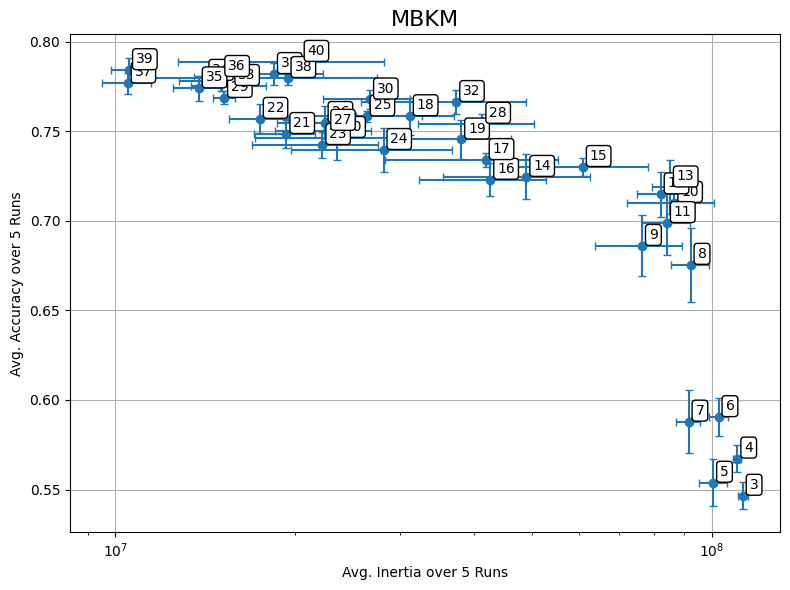

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(plot_df["inertia_mean"], plot_df["acc_mean"], xerr=plot_df["inertia_sem"], yerr=plot_df["acc_sem"], fmt="o", capsize=3)

# Add n_clusters labels
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["n_clusters"].astype(int)),
        (row["inertia_mean"], row["acc_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black"
        )
    )

ax.set_xlabel(f"Avg. Inertia over {no_of_runs} Runs")
ax.set_ylabel(f"Avg. Accuracy over {no_of_runs} Runs")
ax.set_xscale("log")
ax.grid(True)
ax.set_title(f"{method}", fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

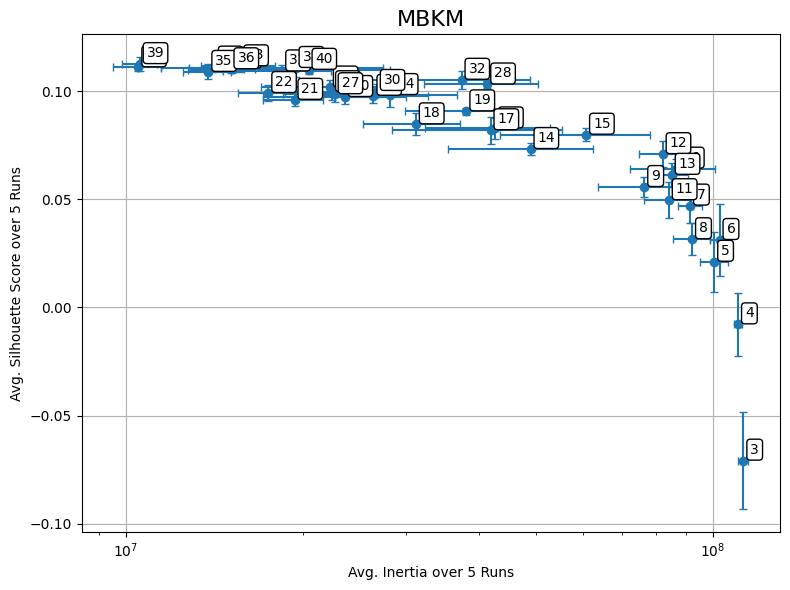

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(plot_df["inertia_mean"], plot_df["sil_mean"], xerr=plot_df["inertia_sem"], yerr=plot_df["sil_sem"], fmt="o", capsize=3)

# Add n_clusters labels
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["n_clusters"].astype(int)),
        (row["inertia_mean"], row["sil_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black"
        )
    )

ax.set_xlabel(f"Avg. Inertia over {no_of_runs} Runs")
ax.set_ylabel(f"Avg. Silhouette Score over {no_of_runs} Runs")
ax.set_xscale("log")
ax.grid(True)
ax.set_title(f"{method}", fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

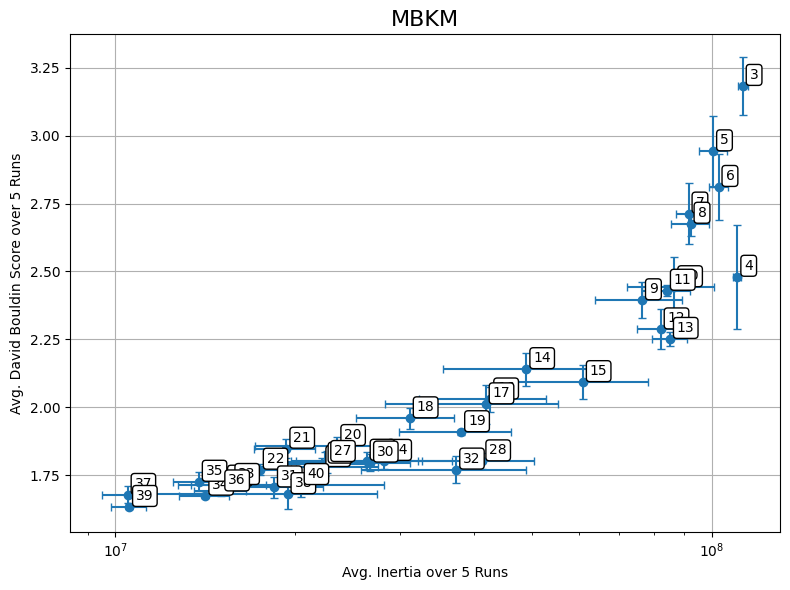

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(plot_df["inertia_mean"], plot_df["david_mean"], xerr=plot_df["inertia_sem"], yerr=plot_df["david_sem"], fmt="o", capsize=3)

# Add n_clusters labels
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["n_clusters"].astype(int)),
        (row["inertia_mean"], row["david_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black"
        )
    )

ax.set_xlabel(f"Avg. Inertia over {no_of_runs} Runs")
ax.set_ylabel(f"Avg. David Bouldin Score over {no_of_runs} Runs")
ax.set_xscale("log")
ax.grid(True)
ax.set_title(f"{method}", fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

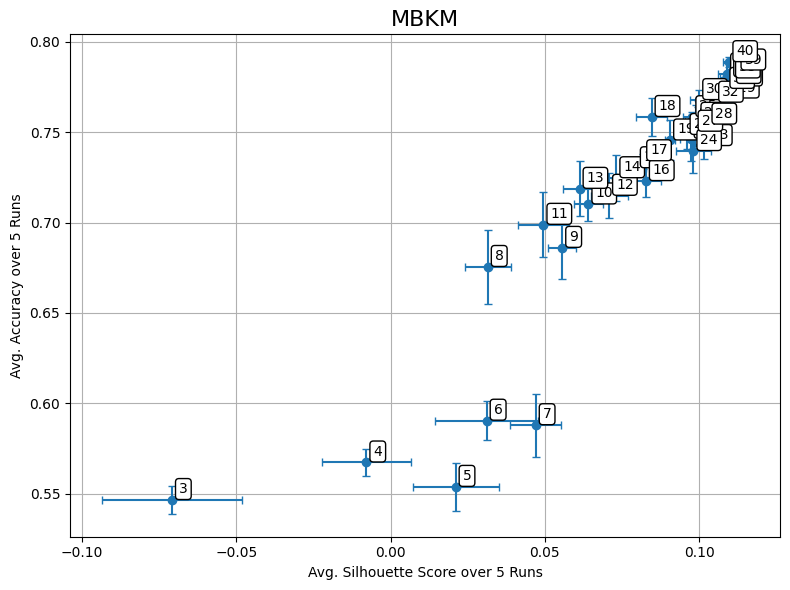

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(plot_df["sil_mean"], plot_df["acc_mean"], xerr=plot_df["sil_sem"], yerr=plot_df["acc_sem"], fmt="o", capsize=3)

# Add n_clusters labels
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["n_clusters"].astype(int)),
        (row["sil_mean"], row["acc_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black"
        )
    )

ax.set_xlabel(f"Avg. Silhouette Score over {no_of_runs} Runs")
ax.set_ylabel(f"Avg. Accuracy over {no_of_runs} Runs")
ax.grid(True)
ax.set_title(f"{method}", fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

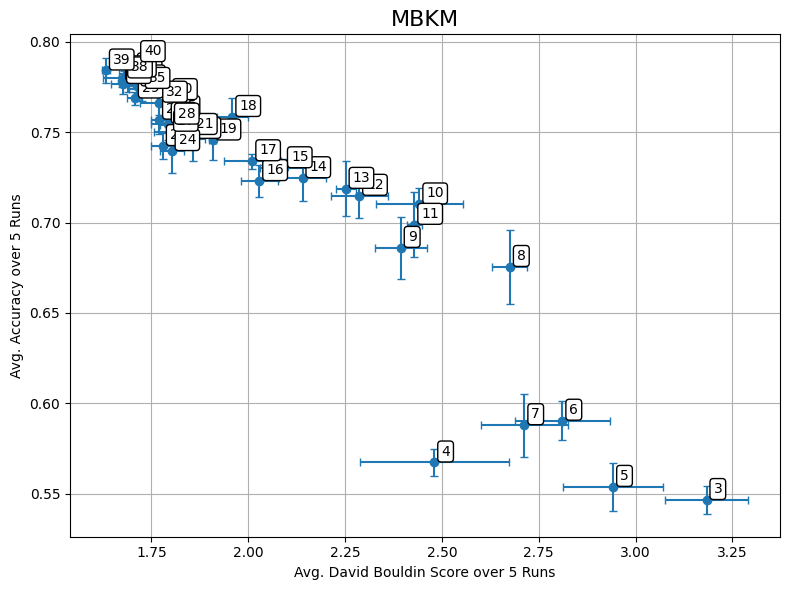

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(plot_df["david_mean"], plot_df["acc_mean"], xerr=plot_df["david_sem"], yerr=plot_df["acc_sem"], fmt="o", capsize=3)

# Add n_clusters labels
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["n_clusters"].astype(int)),
        (row["david_mean"], row["acc_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="black"
        )
    )

ax.set_xlabel(f"Avg. David Bouldin Score over {no_of_runs} Runs")
ax.set_ylabel(f"Avg. Accuracy over {no_of_runs} Runs")
ax.grid(True)
ax.set_title(f"{method}", fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

## Galaxy Uncertainty Analysis

In [ ]:
from projectFunctions import distance_bin_plots, confidence_bin_plots
plt.close('all')


distance_bin_plots(test_subset, xlimits=None, ylimits=None, method=method)
confidence_bin_plots(test_subset, width=1, xlimits=None, ylimits=None, method=method)

## UMAP Clustering Analysis

In [ ]:
umap = UMAP(n_components=2, random_state=20)
umap_features = umap.fit_transform(pca_features)

### Full Feature Space

#### Coloured by Cluster

In [ ]:
clusters_integers = clusters["Cluster"].astype(int)

cmap = plt.get_cmap("tab20", no_of_clusters)
norm = mcolors.BoundaryNorm(np.arange(-0.5, no_of_clusters+0.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

sc = plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters_integers, cmap=cmap, s=2, norm=norm, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(no_of_clusters))
cbar.set_label('Cluster')
plt.clim(-0.5, no_of_clusters-0.5)

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Cluster')

plt.xlabel('Arbitrary Units')
plt.ylabel('Arbitrary Units')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}

type_colours = ["#9467bd", '#ffbb78', "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order)+0.5, 1),cmap_type.N)

type_ints = clusters['Dominant_Type'].map(class_to_int)

plt.figure(figsize=(10, 8))

sc = plt.scatter(umap_features[:,0],umap_features[:,1],c=type_ints,cmap=cmap_type,norm=norm_type,s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Predicted Morphological Label')

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Predicted Type')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Predicted Type')

plt.xlabel('Arbitrary Units')
plt.ylabel('Arbitrary Units')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Predicted_Type.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Uncertainty

In [ ]:
mask = ((clusters[f"Assigned_{prefix}"] < 10)   #< clusters[f"Assigned_{prefix}"].max())
        & (~clusters['Cluster'].isin(low_member_clusters)) 
        & (~clusters['Cluster'].isin(low_percentage_clusters)) )
selected_features = umap_features[mask.to_numpy()]
selected_distances = clusters.loc[mask, f"Assigned_{prefix}"]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
#sc = plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters[f'Assigned_{prefix}'], cmap='cool', s=2, alpha=0.5)
sc = plt.scatter(selected_features[:, 0], selected_features[:, 1], c=selected_distances, cmap='cool', s=2, alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label(f'Assigned {prefix}')

plt.title(f'Full {method} Feature Space UMAP: Colored by {prefix}')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Assigned_{prefix}.png'), dpi=300, bbox_inches='tight')
plt.show()

### Test Set on Feature Space

In [ ]:
mask = pca_features.index.isin(test_subset.index)

#### Coloured by Cluster

In [ ]:
colors = plt.cm.tab20.colors
cmap = ListedColormap(colors[:no_of_clusters])
cluster_labels, cluster_ints = np.unique(test_subset['Cluster'], return_inverse=True)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=cluster_ints, cmap=cmap, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(cluster_labels)))
cbar.set_label('Cluster')
cbar.set_ticks(np.arange(len(cluster_labels)))
cbar.set_ticklabels(cluster_labels)
plt.clim(-0.5, len(cluster_labels)-0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Cluster')

plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
type_ints = test_subset['Volunteer_Label'].map(class_to_int)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=type_ints, cmap=cmap_type, norm=norm_type, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Volunteer Label')

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Volunteer Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Volunteer Label')

plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Volunteer_Label.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
correct = (test_subset['Volunteer_Label'] == test_subset['Predicted_Label']).to_numpy()

plt.figure(figsize=(8, 8))

plt.scatter(umap_features[~mask, 0],umap_features[~mask, 1],c='lightgrey',s=2)
plt.scatter(umap_features[mask][~correct, 0],umap_features[mask][~correct, 1],c='salmon',s=2,label='Incorrect', alpha=0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Accuracy of Predicted Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Accuracy of Predicted Label')
plt.xticks([])
plt.yticks([]) 
plt.legend()
plt.show()

## Interactive UMAP (Test Set on Feature Space)

In [ ]:
from IPython.display import display
%matplotlib widget

um_feats = pd.DataFrame(umap_features, index=pca_features.index, columns=['0', '1'])
um_feats = um_feats[mask]
x = um_feats['0'].values
y = um_feats['1'].values
labels = um_feats.index.to_numpy()
plt.close('all')
fig, ax = plt.subplots(figsize=(5,5))
sc = ax.scatter(x, y, c='k', alpha=0.1, s=1)

clicked = [] # keep track of selected indices

def on_click(event):
    if event.inaxes != ax:
        return
    click_x, click_y = event.xdata, event.ydata
    dist = np.hypot(x - click_x, y - click_y)
    i = np.argmin(dist)

    msg = f"Index: {labels[i]} (x={x[i]}, y={y[i]})"
    clicked.append(labels[i])

    # this makes sure it shows in Jupyter output
    display(msg)

    # mark and label point on plot
    ax.plot(x[i], y[i], 'ro', markersize=1)
    ax.annotate(labels[i], (x[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=2, color="red")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

#### Plotting Selected Galaxies

In [ ]:
plt.close('all')
%matplotlib inline
clicked = np.array(clicked)
filenames_to_find = set(clicked.astype(str) + '.png')

# collect paths of images to display
img_paths = []
for root, dirs, files in os.walk(img_dir):
    for file in files:
        if file in filenames_to_find:
            img_paths.append(os.path.join(root, file))

# display images in a grid
n_cols = 5  # number of columns in the grid
n_rows = (len(img_paths) + n_cols - 1) // n_cols  # compute rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()  # flatten in case of multiple rows

for ax, img_path in zip(axes, img_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # hide axes
    ax.set_title(os.path.basename(img_path), fontsize=8)

# hide any unused axes
for ax in axes[len(img_paths):]:
    ax.axis('off')

plt.suptitle('Selected Galaxy Images', fontsize=16)
plt.tight_layout()
plt.show()